In [1]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import pandas as pd
import muon as mu
import scanpy as sc
import scirpy as ir
np.random.seed(42)
import random
random.seed(42)

import sys
sys.path.append("/ihome/ylee/yiz133/Code/Data processing/functions")
import mdata_utils

2026-02-19 17:23:55.043555: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-02-19 17:23:55.043923: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-19 17:23:55.094584: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-19 17:23:57.493130: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To tur

# GEX

In [14]:
GSE = 'GSE156718'
data_path = "/ix1/ylee/Yifan_Zhang/Code_data/external/GSE156718 CD4 iLN"
mdata_ori = mu.read(data_path + "/GSE156718.h5mu")
mdata = mdata_ori.copy()

In [15]:
%cd $data_path

/ix1/ylee/Yifan_Zhang/Code_data/external/GSE156718 CD4 iLN


In [16]:
mdata.obs['GSE'] = GSE
mdata.obs['GSM'] = mdata.obs['batch']
mdata.obs['tissue'] = mdata['gex'].obs['tissue']


In [17]:
mdata.obs['batch'].value_counts()

batch
mLN    6038
iLN    5818
Name: count, dtype: int64

In [18]:
mdata['gex'].obs['tissue'].value_counts()

tissue
iLN       3260
mLN       3132
Spleen    2506
CNS        413
Name: count, dtype: int64

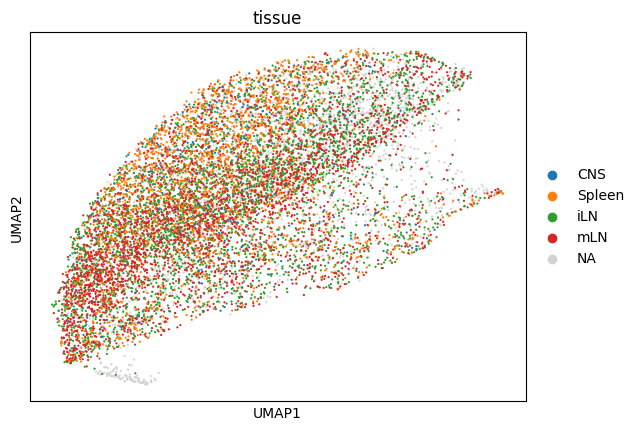

In [19]:
sc.pp.pca(mdata["gex"], n_comps=50)
sc.pp.neighbors(mdata["gex"], n_neighbors = 50)
sc.tl.umap(mdata["gex"], min_dist=0.5, spread=1.0)
sc.pl.umap(mdata["gex"], color=['tissue'])


In [20]:
## data specific features
mdata.obs['condition'] = 'EAE'
mdata['gex'].obs['sample_id'] = 'mixed'

# mdata['gex'].obs['cell_type'] = 'CD4'


In [21]:
mdata = mdata_utils.pp_EAE(mdata, celltype_score = 0.4, cellstate_score = 0.4, topN_variable = None)

In [22]:
print(mdata['gex'].obs['cell_type'].value_counts())
print(mdata['gex'].obs['state'].value_counts())

cell_type
CD4         2980
CD4_Treg     315
CD8          223
CD4_Th17      15
CD4_Th2        1
CD4_Th1        1
Name: count, dtype: int64
state
Early_activ        1586
Naive               483
Memory_core         470
Proliferating       406
Exhaustion_core     362
Tcf7_stem           356
IFN_stim            165
Cytotoxic           121
Effector_core        29
Name: count, dtype: int64


In [23]:
sc.pp.pca(mdata["gex"], n_comps=50)
sc.pp.neighbors(mdata["gex"], n_neighbors = 50)
sc.tl.umap(mdata["gex"], min_dist=0.5, spread=1.0)

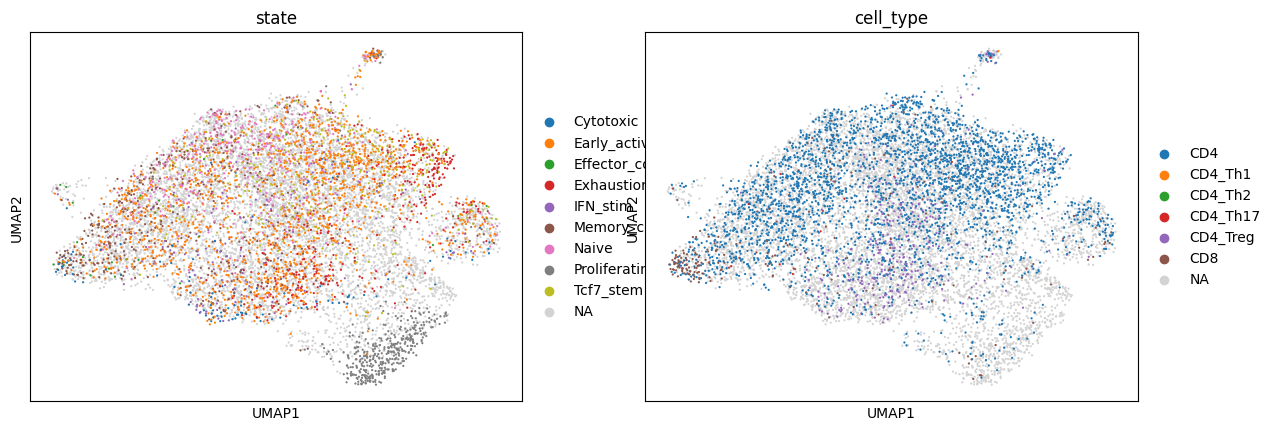

In [24]:
sc.pl.umap(mdata["gex"], color=['state', 'cell_type'])

In [ ]:
## Cell State Annotation Based on HVGs Between Clusters

This section performs:
1. Unsupervised clustering (Leiden)
2. Differential expression analysis to find cluster-specific marker genes
3. Annotation using literature-based CD4+ T cell markers
4. Refined cell state assignment based on cluster profiles

NameError: name 'aa' is not defined

In [ ]:
# Step 1: Leiden clustering for unsupervised cell grouping
sc.tl.leiden(mdata['gex'], resolution=0.8, key_added='leiden')
print(f"Found {mdata['gex'].obs['leiden'].nunique()} clusters")
sc.pl.umap(mdata['gex'], color=['leiden', 'state', 'cell_type'], ncols=3, wspace=0.3)

In [ ]:
# Step 2: Find differentially expressed genes (HVGs) between clusters
sc.tl.rank_genes_groups(mdata['gex'], groupby='leiden', method='wilcoxon', key_added='rank_genes_leiden')

# Display top 10 marker genes per cluster
sc.pl.rank_genes_groups(mdata['gex'], n_genes=10, sharey=False, key='rank_genes_leiden')

In [ ]:
# Step 3: Define literature-based marker genes for CD4+ T cell states
cd4_state_markers = {
    'Naive': ['Ccr7', 'Sell', 'Lef1', 'Tcf7', 'Il7r', 'Bach2'],
    'Tcm': ['Ccr7', 'Sell', 'Il7r', 'Tcf7', 'Bcl2', 'Id3'],
    'Tem': ['S100a4', 'Ccl5', 'Il7r', 'Gzma', 'Cx3cr1', 'Tbx21'],
    'Th1': ['Tbx21', 'Ifng', 'Stat1', 'Stat4', 'Cxcr3', 'Tnf'],
    'Th2': ['Gata3', 'Stat6', 'Il4', 'Il5', 'Ccr4', 'Il1rl1'],
    'Th17': ['Rorc', 'Rora', 'Stat3', 'Il17a', 'Ccr6', 'Il23r'],
    'Treg': ['Foxp3', 'Il2ra', 'Ctla4', 'Ikzf2', 'Il10', 'Nrp1'],
    'Tfh': ['Cxcr5', 'Pdcd1', 'Bcl6', 'Icos', 'Il21', 'Ascl2'],
    'Tex': ['Pdcd1', 'Tox', 'Lag3', 'Tigit', 'Havcr2', 'Ctla4'],
    'Cycling': ['Mki67', 'Top2a', 'Tyms', 'Cdk1', 'Pcna', 'Birc5'],
    'Early_Act': ['Cd69', 'Nr4a1', 'Nr4a2', 'Fos', 'Jun', 'Egr1'],
    'IFN_Stim': ['Isg15', 'Ifit1', 'Ifit3', 'Mx1', 'Oas1a', 'Irf7'],
}
print(f"Defined {len(cd4_state_markers)} cell state signatures")

In [ ]:
# Step 3: Define literature-based marker genes for CD4+ T cell states
# Reference: Mouse T cell markers from CellMarker, PanglaoDB, and published EAE studies

cd4_state_markers = {
    # Naive T cells - quiescent, recently emigrated from thymus
    'Naive': ['Ccr7', 'Sell', 'Lef1', 'Tcf7', 'Il7r', 'Cd27', 'Cd28', 'Bach2', 'Satb1'],
    
    # Central memory - lymph node homing, stem-like properties  
    'Tcm': ['Ccr7', 'Sell', 'Il7r', 'Cd27', 'Tcf7', 'Bcl2', 'Lef1', 'Id3'],
    
    # Effector memory - tissue homing, rapid effector function
    'Tem': ['S100a4', 'Ccl5', 'Il7r', 'Gzma', 'Prf1', 'Cx3cr1', 'Klrg1', 'Tbx21'],
    
    # Th1 - IFNg producers, anti-intracellular pathogen
    'Th1': ['Tbx21', 'Ifng', 'Stat1', 'Stat4', 'Cxcr3', 'Ccr5', 'Tnf', 'Il2', 'Il12rb1', 'Il18r1'],
    
    # Th2 - IL4/5/13 producers, anti-helminth, allergy
    'Th2': ['Gata3', 'Stat6', 'Il4', 'Il5', 'Il13', 'Ccr4', 'Ccr8', 'Il1rl1', 'Areg'],
    
    # Th17 - IL17 producers, key in EAE/autoimmunity
    'Th17': ['Rorc', 'Rora', 'Stat3', 'Batf', 'Il17a', 'Il17f', 'Il22', 'Il21', 'Ccr6', 'Il23r', 'Ahr'],
    
    # Treg - Foxp3+ regulatory T cells
    'Treg': ['Foxp3', 'Il2ra', 'Ctla4', 'Ikzf2', 'Icos', 'Tigit', 'Il10', 'Tgfb1', 'Nrp1'],
    
    # Tfh - follicular helper, B cell help
    'Tfh': ['Cxcr5', 'Pdcd1', 'Bcl6', 'Icos', 'Il21', 'Sh2d1a', 'Cd40lg', 'Ascl2'],
    
    # Exhausted/Dysfunctional - chronic stimulation
    'Tex': ['Pdcd1', 'Tox', 'Lag3', 'Tigit', 'Havcr2', 'Ctla4', 'Entpd1', 'Cd244a'],
    
    # Proliferating - cell cycle active
    'Cycling': ['Mki67', 'Top2a', 'Tyms', 'Cdk1', 'Pcna', 'Mcm5', 'Birc5', 'Ccnb2'],
    
    # Early activated - recently stimulated
    'Early_Act': ['Cd69', 'Nr4a1', 'Nr4a2', 'Fos', 'Jun', 'Egr1', 'Icos', 'Cd44'],
    
    # IFN-stimulated - Type I IFN response
    'IFN_Stim': ['Isg15', 'Ifit1', 'Ifit3', 'Mx1', 'Oas1a', 'Stat1', 'Irf7', 'Gbp2'],
}

print(f"Defined {len(cd4_state_markers)} cell state signatures")

# TCR

In [ ]:
# mdata = mdata_ori.copy()
mdata['airr'].obs['sample_id'] = mdata.obs['sample_id']

ir.pp.index_chains(mdata)
ir.tl.chain_qc(mdata)

ir.pp.ir_dist(mdata)
ir.tl.define_clonotypes(mdata, receptor_arms="all", dual_ir="primary_only", within_group = 'sample_id')

meta_airr = ir.get.airr(mdata['airr'], ["cdr3_aa", "v_call", "j_call"] ,  ('VJ_1', 'VDJ_1'))

df2_filtered = meta_airr.loc[:, ~meta_airr.columns.isin(mdata.obs.columns)]
mdata.obs = mdata.obs.join(df2_filtered)
mdata.update()

# mdata.obs = mdata.obs.reindex(mdata.mod['gex'].obs.index)
ir.tl.clonal_expansion(mdata)


In [ ]:
mdata

MuData object with n_obs × n_vars = 11856 × 10781
  obs:	'batch', 'GSE', 'GSM', 'tissue', 'condition', 'state', 'cell_type', 'sample_id', 'VJ_1_cdr3_aa', 'VJ_1_v_call', 'VJ_1_j_call', 'VDJ_1_cdr3_aa', 'VDJ_1_v_call', 'VDJ_1_j_call'
  2 modalities
    airr:	11856 x 0
      obs:	'sample_id', 'receptor_type', 'receptor_subtype', 'chain_pairing', 'clone_id', 'clone_id_size', 'clonal_expansion'
      uns:	'chain_indices', 'ir_dist_nt_identity', 'clone_id'
      obsm:	'airr', 'chain_indices'
    gex:	10848 x 10781
      obs:	'TCR_clonotype_frequency', 'tissue', 'sample_id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_genes', 'n_counts', 'CD4score', 'CD8score', 'Tregscore', 'Th17score', 'cell_type', 'IFN_stimscore', 'Activationscore', 'Exhaustscore', 'Mem_Naivescore', 'state'
      var:	'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells'
      uns:	'log1p'

In [ ]:
count = (mdata['airr'].obs['clone_id_size'] == 1).sum()
print(count)

8608


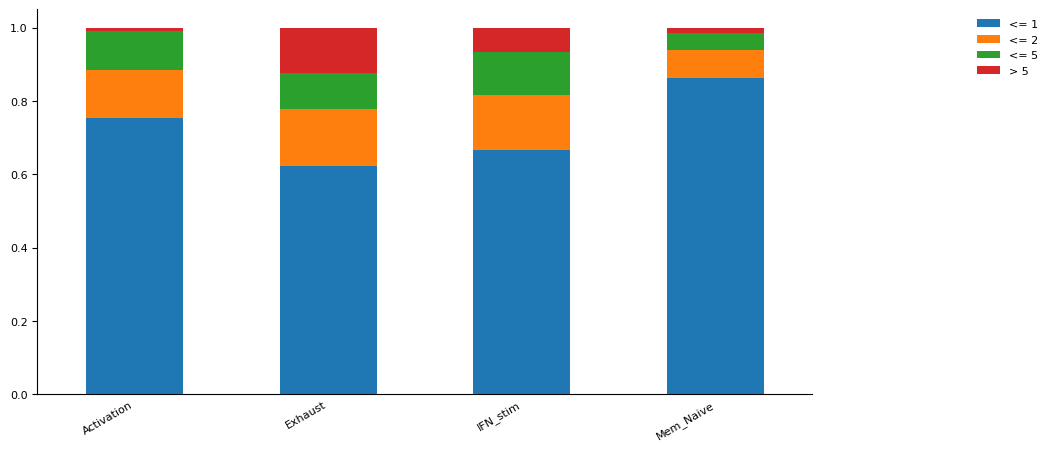

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
_ = ir.pl.clonal_expansion(
    mdata, 
    target_col="clone_id",
    groupby="state",  # Use the new combined column
    breakpoints=(1, 2, 5), 
    ax = ax
    #normalize=False
)

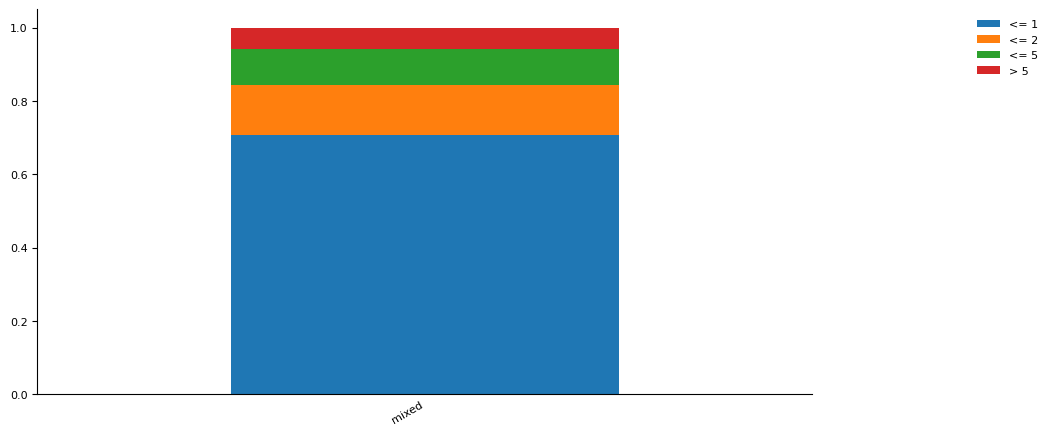

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
_ = ir.pl.clonal_expansion(
    mdata, 
    target_col="clone_id",
    groupby= 'sample_id',  # Use the new combined column
    breakpoints=(1, 2, 5), 
    ax = ax
    #normalize=False
)

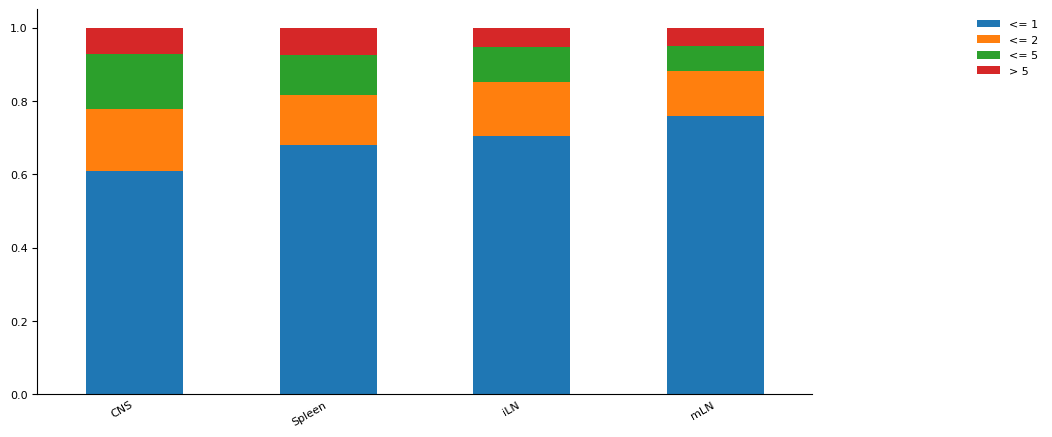

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
_ = ir.pl.clonal_expansion(
    mdata, 
    target_col="clone_id",
    groupby= 'tissue',  # Use the new combined column
    breakpoints=(1, 2, 5), 
    ax = ax
    #normalize=False
)

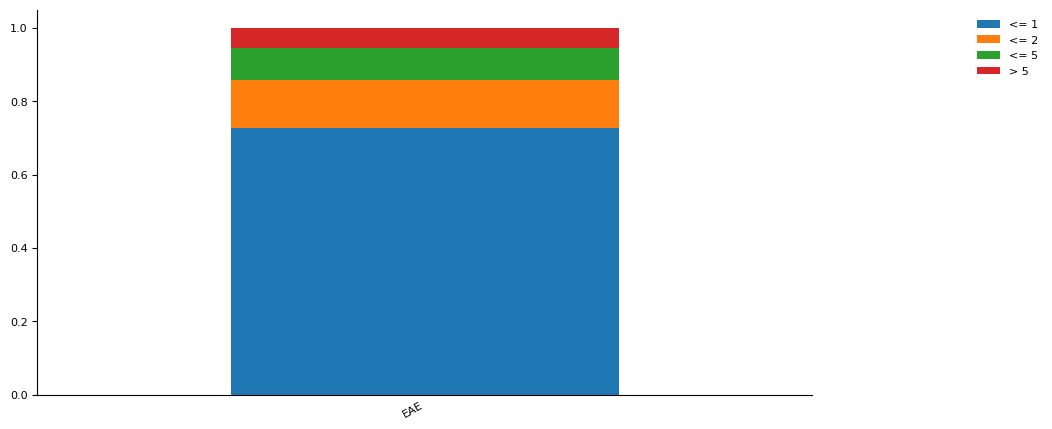

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
_ = ir.pl.clonal_expansion(
    mdata, 
    target_col="clone_id",
    groupby= 'condition',  # Use the new combined column
    breakpoints=(1, 2, 5), 
    ax = ax
    #normalize=False
)

In [ ]:
# mdata.write('yz_processed.h5mu')
# mdata.write('yz_processed_allGenes_annotateByRef.h5mu')
mdata.write('yz_processed_allGenes_annotateByScore.h5mu')

In [ ]:
aa

NameError: name 'aa' is not defined

In [ ]:
sc.pp.pca(mdata["gex"], svd_solver="arpack", n_comps=50)
sc.pp.neighbors(mdata["gex"], n_neighbors = 50)
sc.tl.umap(mdata["gex"], min_dist=0.5, spread=1.0)
sc.pl.umap(mdata["gex"], color=['batch', 'cell_type', 'state', 'tissue'], ncols=2,)

In [ ]:
# markers_in = []
# for i in ['Ccr6', 'Il22', 'Il17', 'Il17a'] + genes:
#     if i in mdata["gex"].var_names:
#         markers_in.append(i) 
# mu.pl.embedding(mdata["gex"], basis="umap", color= markers_in,  wspace = 0.1, ncols=2, vmin=0)

In [ ]:
mdata.obs['cell_type'].value_counts()